In [59]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import merlin
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import torch

In [60]:
dataset = make_circles(n_samples=500)
X = dataset[0]
y = dataset[1]

min_vals = X.min(axis=0, keepdims=True)
max_vals = X.max(axis=0, keepdims=True)
X = (X - min_vals) / np.clip(max_vals - min_vals, a_min=1e-6, a_max=None)



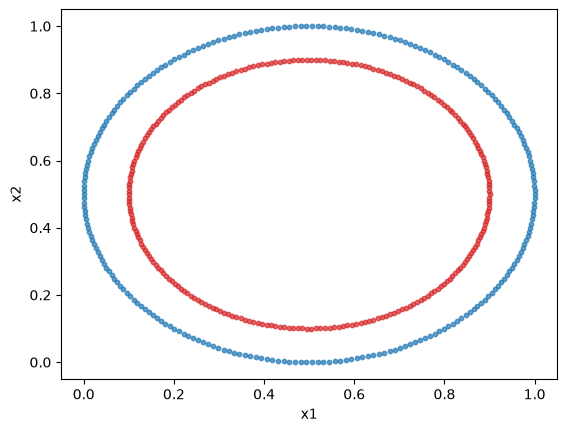

In [61]:
# Plotting the dataset
class_1 = []
class_2 = []

for features, label in zip(X, y, strict=True):
    if label == 0:
        class_1.append(features)
    else:
        class_2.append(features)

class_1 = np.array(class_1)
class_2 = np.array(class_2)

plt.scatter(class_1[:, 0], class_1[:, 1], s=10, color="tab:blue", alpha=0.7)
plt.scatter(class_2[:, 0], class_2[:, 1], s=10, color="tab:red", alpha=0.7)
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42,
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")

Train size: 425 samples
Test size: 75 samples


In [63]:
layer = merlin.QuantumLayer.simple(input_size=2, output_size=2)

In [64]:
epochs = 250
lr = 0.02
optimizer = torch.optim.Adam(layer.parameters(), lr=lr)

train_accuracies = []
train_losses = []
test_accuracies = []
test_losses = []

for _ in range(epochs):
    # Train the model
    layer.train()
    optimizer.zero_grad()
    logits = layer(X_train)
    loss = torch.nn.functional.cross_entropy(logits, y_train)
    loss.backward()
    optimizer.step()

    # Evaluate the model on the train set
    train_preds = logits.argmax(dim=1)
    train_acc = (train_preds == y_train).float().mean().item()
    train_accuracies.append(train_acc)
    train_losses.append(loss.item())

    # Evaluate the accuracy of the model on the test set
    layer.eval()
    logits = layer(X_test)
    test_preds = logits.argmax(dim=1)
    test_acc = (test_preds == y_test).float().mean().item()
    test_accuracies.append(test_acc)
    with torch.no_grad():
        loss = torch.nn.functional.cross_entropy(logits, y_test)
        test_losses.append(loss.item())




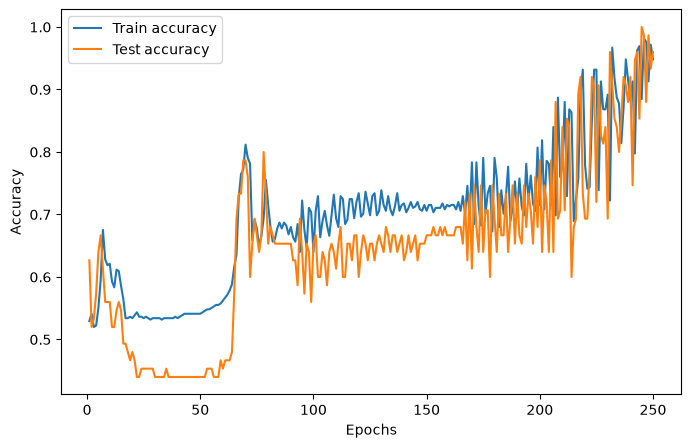

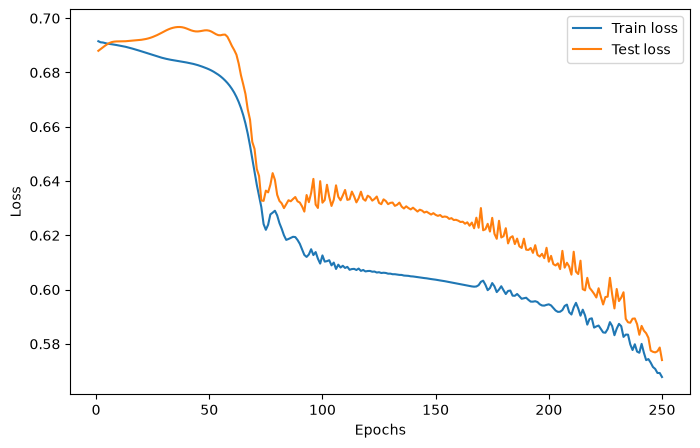

In [65]:
epoch_range = range(1, epochs + 1)

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, train_accuracies, label="Train accuracy")
plt.plot(epoch_range, test_accuracies, label="Test accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, train_losses, label="Train loss")
plt.plot(epoch_range, test_losses, label="Test loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [66]:
layer.eval()
with torch.no_grad():
    train_preds = layer(X_train).argmax(dim=1)
    test_preds = layer(X_test).argmax(dim=1)
    train_acc = (train_preds == y_train).float().mean().item()
    test_acc = (test_preds == y_test).float().mean().item()

print(f"The accuracy of the model on the training set is {train_acc}")
print(f"The accuracy of the model on the test set is {test_acc}")

The accuracy of the model on the training set is 0.9717646837234497
The accuracy of the model on the test set is 0.9599999785423279


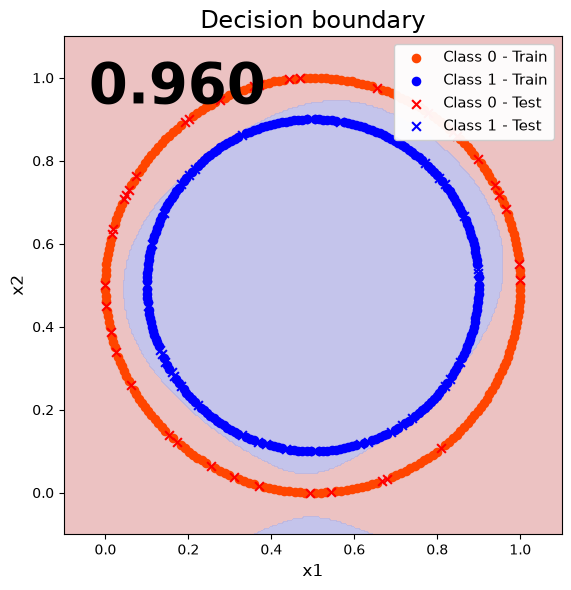

In [67]:
# Plot range from full dataset
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

# Grid
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Predict on grid
layer.eval()
with torch.no_grad():
    out = layer(grid_tensor)
    Z = torch.argmax(out, dim=1)

Z = Z.cpu().numpy().reshape(xx.shape)

# Convert tensors once
X_train_np = X_train.detach().cpu().numpy()
X_test_np = X_test.detach().cpu().numpy()

# Background
bg_cmap = ListedColormap(["#e8b3b3", "#b6b6e6"])
plt.figure(figsize=(8.4, 6.0))
plt.contourf(xx, yy, Z, levels=np.arange(-0.5, 2, 1), cmap=bg_cmap, alpha=0.8)

# Train points
plt.scatter(
    X_train_np[y_train == 0, 0],
    X_train_np[y_train == 0, 1],
    c="orangered",
    s=35,
    marker="o",
    label="Class 0 - Train",
)
plt.scatter(
    X_train_np[y_train == 1, 0],
    X_train_np[y_train == 1, 1],
    c="blue",
    s=35,
    marker="o",
    label="Class 1 - Train",
)

# Test points
plt.scatter(
    X_test_np[y_test == 0, 0],
    X_test_np[y_test == 0, 1],
    c="red",
    s=40,
    marker="x",
    linewidths=1.5,
    label="Class 0 - Test",
)
plt.scatter(
    X_test_np[y_test == 1, 0],
    X_test_np[y_test == 1, 1],
    c="blue",
    s=40,
    marker="x",
    linewidths=1.5,
    label="Class 1 - Test",
)

# Accuracy text
plt.text(
    0.05,
    0.95,
    f"{test_acc:.3f}",
    transform=plt.gca().transAxes,
    fontsize=40,
    fontweight="bold",
    ha="left",
    va="top",
    color="black",
)

plt.title("Decision boundary", fontsize=17)
plt.xlabel("x1", fontsize=12)
plt.ylabel("x2", fontsize=12)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(loc="upper right", fontsize=11, framealpha=0.95)
plt.tight_layout()
plt.show()